In [1]:
html_doc = """
<html><head><title>The Dormouse's story</title></head>
<body>
<p class="title"><b>The Dormouse's story</b></p>

<p class="story">Once upon a time there were three little sisters; and their names were
<a href="http://example.com/elsie" class="sister" id="link1">Elsie</a>,
<a href="http://example.com/lacie" class="sister" id="link2">Lacie</a> and
<a href="http://example.com/tillie" class="sister" id="link3">Tillie</a>;
and they lived at the bottom of a well.</p>

<p class="story">...</p>
"""

In [2]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(html_doc, 'html.parser')

print(soup.prettify())
# <html>
#  <head>
#   <title>
#    The Dormouse's story
#   </title>
#  </head>
#  <body>
#   <p class="title">
#    <b>
#     The Dormouse's story
#    </b>
#   </p>
#   <p class="story">
#    Once upon a time there were three little sisters; and their names were
#    <a class="sister" href="http://example.com/elsie" id="link1">
#     Elsie
#    </a>
#    ,
#    <a class="sister" href="http://example.com/lacie" id="link2">
#     Lacie
#    </a>
#    and
#    <a class="sister" href="http://example.com/tillie" id="link2">
#     Tillie
#    </a>
#    ; and they lived at the bottom of a well.
#   </p>
#   <p class="story">
#    ...
#   </p>
#  </body>
# </html>

<html>
 <head>
  <title>
   The Dormouse's story
  </title>
 </head>
 <body>
  <p class="title">
   <b>
    The Dormouse's story
   </b>
  </p>
  <p class="story">
   Once upon a time there were three little sisters; and their names were
   <a class="sister" href="http://example.com/elsie" id="link1">
    Elsie
   </a>
   ,
   <a class="sister" href="http://example.com/lacie" id="link2">
    Lacie
   </a>
   and
   <a class="sister" href="http://example.com/tillie" id="link3">
    Tillie
   </a>
   ;
and they lived at the bottom of a well.
  </p>
  <p class="story">
   ...
  </p>
 </body>
</html>



In [3]:
soup.title
# <title>The Dormouse's story</title>

soup.title.name
# u'title'

soup.title.string
# u'The Dormouse's story'

soup.title.parent.name
# u'head'

soup.p
# <p class="title"><b>The Dormouse's story</b></p>

soup.p['class']
# u'title'

soup.a
# <a class="sister" href="http://example.com/elsie" id="link1">Elsie</a>

soup.find_all('a')
# [<a class="sister" href="http://example.com/elsie" id="link1">Elsie</a>,
#  <a class="sister" href="http://example.com/lacie" id="link2">Lacie</a>,
#  <a class="sister" href="http://example.com/tillie" id="link3">Tillie</a>]

soup.find(id="link3")
# <a class="sister" href="http://example.com/tillie" id="link3">Tillie</a>

<a class="sister" href="http://example.com/tillie" id="link3">Tillie</a>

In [4]:
for link in soup.find_all('a'):
    print(link.get('href'))
# http://example.com/elsie
# http://example.com/lacie
# http://example.com/tillie

http://example.com/elsie
http://example.com/lacie
http://example.com/tillie


In [5]:
print(soup.get_text())
# The Dormouse's story
#
# The Dormouse's story
#
# Once upon a time there were three little sisters; and their names were
# Elsie,
# Lacie and
# Tillie;
# and they lived at the bottom of a well.
#
# ...


The Dormouse's story

The Dormouse's story
Once upon a time there were three little sisters; and their names were
Elsie,
Lacie and
Tillie;
and they lived at the bottom of a well.
...



In [12]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

def get_books(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    book_list = []

    # Selecting the <h3><a> tag and extracting the 'title' attribute
    for h3 in soup.find_all('h3'):
        a_tag = h3.find('a')
        title = a_tag['title']
        price = soup.find('p', class_='price_color').text
        book_list.append({'Title': title, 'Price': price})

    return book_list

# Part 1 & 2: Scraping 100 books (5 pages)
base_url = "http://books.toscrape.com/catalogue/page-{}.html"
all_books = []
for i in range(1, 6):
    all_books.extend(get_books(base_url.format(i)))

df_all = pd.DataFrame(all_books)
print(f"Total books collected: {len(df_all)}")

Total books collected: 100


In [16]:
# Cleaning price data: removing '£' and converting to float
df_all['Price_Numeric'] = df_all['Price'].str.replace('£', '').str.replace('Â', '').astype(float)

# Sort and display top 10 most expensive
df_expensive = df_all.sort_values(by='Price_Numeric', ascending=False).head(10)
print(df_expensive[['Title', 'Price_Numeric']])

                                                Title  Price_Numeric
40                     Slow States of Collapse: Poems          57.31
41                              Reasons to Stay Alive          57.31
42                        Private Paris (Private #10)          57.31
43  #HigherSelfie: Wake Up Your Life. Free Your So...          57.31
52  Throwing Rocks at the Google Bus: How Growth B...          57.31
53                                    This One Summer          57.31
54                                             Thirst          57.31
55        The Torch Is Passed: A Harding Family Story          57.31
51  Tsubasa: WoRLD CHRoNiCLE 2 (Tsubasa WoRLD CHRo...          57.31
50  Unbound: How Eight Technologies Made Us Human,...          57.31


<Figure size 800x600 with 0 Axes>

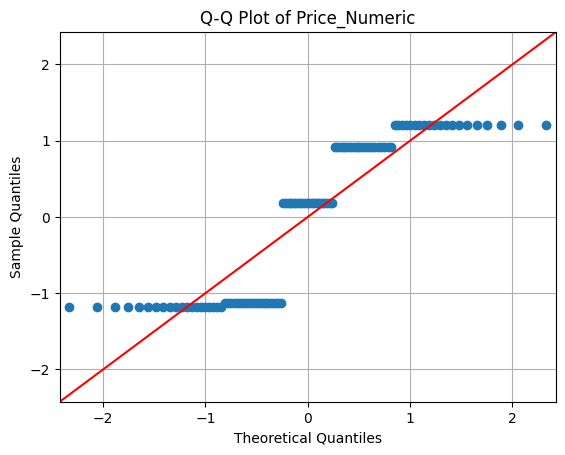

In [17]:
# Generating the Q-Q Plot
plt.figure(figsize=(8, 6))
sm.qqplot(df_all['Price_Numeric'], line='45', fit=True)
plt.title('Q-Q Plot of Price_Numeric')
plt.grid(True)
plt.show()

In [19]:
shapiro_test = stats.shapiro(df_all['Price_Numeric'])
print(f"Shapiro-Wilk Statistic: {shapiro_test.statistic:.4f}")
print(f"P-value: {shapiro_test.pvalue:.4f}")

# Interpretation
alpha = 0.05
if shapiro_test.pvalue > alpha:
    print("Result: Fail to reject H0. The data appears to follow a normal distribution.")
else:
    print("Result: Reject H0. The data does not follow a normal distribution.")

Shapiro-Wilk Statistic: 0.7842
P-value: 0.0000
Result: Reject H0. The data does not follow a normal distribution.


In [21]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. 설정: 타겟 카테고리 리스트
categories = [
    'Travel', 'Mystery', 'Historical Fiction', 'Sequential Art', 'Classics',
    'Philosophy', 'Romance', 'Womens Fiction', 'Fiction', 'Childrens'
]

# 카테고리 이름을 URL 형식에 맞게 변환 (소문자, 공백은 하이픈)
def format_cat_name(name):
    return name.lower().replace(' ', '-')

all_books_data = []
base_url = "http://books.toscrape.com/catalogue/category/books/{}_{}/index.html"

# 2. 데이터 크롤링 (각 카테고리별로 10개씩)
# 실제 사이트의 카테고리별 고유 ID 숫자를 맞추기 위해 반복문 사용
# (참고: 실제 실습 환경의 구조에 따라 URL 패턴은 약간 다를 수 있습니다)
for idx, cat in enumerate(categories, start=2): # 보통 Travel이 2번부터 시작
    cat_url_name = format_cat_name(cat)
    target_url = base_url.format(cat_url_name, idx)

    response = requests.get(target_url)
    if response.status_code != 200: continue # 페이지가 없으면 건너뜀

    soup = BeautifulSoup(response.text, 'html.parser')
    books = soup.find_all('article', class_='product_pod')[:10] # 카테고리당 10개

    for book in books:
        title = book.h3.a['title']
        price_text = book.find('p', class_='price_color').text
        # 숫자만 추출하여 새로운 컬럼 생성
        price_num = float(price_text.replace('£', '').replace('Â', ''))

        all_books_data.append({
            'Category': cat,
            'Title': title,
            'Price': price_text,
            'Price_Numeric': price_num
        })

# 3. 데이터프레임 생성
df_books_dataset = pd.DataFrame(all_books_data)

# 4. 이미지와 동일하게 내림차순 정렬 및 상위 출력
# 가장 비싼 책이 위로 오도록 정렬 (ascending=False)
result = df_books_dataset.sort_values(by='Price_Numeric', ascending=False)

# 결과 확인
print(result.head(10))

              Category                                              Title  \
46            Classics                                            Candide   
51          Philosophy       The Death of Humanity: and the Case for Life   
93           Childrens  The White Cat and the Monk: A Retelling of the...   
70      Womens Fiction  I Had a Nice Time And Other Lies...: How to fi...   
47            Classics                                        Animal Farm   
7               Travel                   A Year in Provence (Provence #1)   
12             Mystery                                The Past Never Ends   
92           Childrens                    The Secret of Dreadwillow Carse   
66             Romance                   Suddenly in Love (Lake Haven #1)   
22  Historical Fiction            A Flight of Arrows (The Pathfinders #2)   

      Price  Price_Numeric  
46  Â£58.63          58.63  
51  Â£58.11          58.11  
93  Â£58.08          58.08  
70  Â£57.36          57.36  
47  Â£5

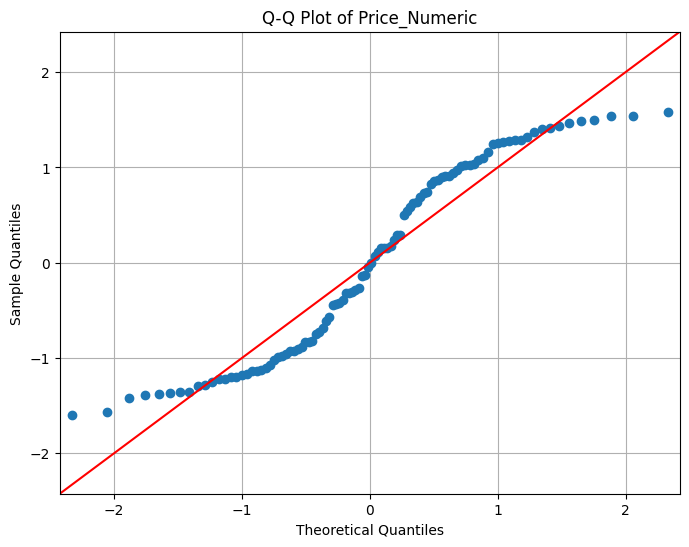

------------------------------
○ Shapiro-Wilk Test Statistic
Statistic: 0.9158
p-value: 0.0000
------------------------------
해석: 데이터가 정규분포를 따르지 않습니다. (H0 기각)


In [22]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

# 1. 그래프 크기 및 레이아웃 설정
fig, ax = plt.subplots(figsize=(8, 6))

# 2. Q-Q Plot 그리기 (이미지와 동일한 스타일)
# line='45'는 빨간색 기준선을 의미합니다.
sm.qqplot(df_books_dataset['Price_Numeric'], line='45', fit=True, ax=ax)

# 3. 이미지와 똑같이 타이틀 및 라벨 설정
ax.set_title('Q-Q Plot of Price_Numeric')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')

# 4. 격자(Grid) 추가
ax.grid(True)

# 5. 그래프 화면 표시
plt.show()

# 6. Shapiro-Wilk Test 통계량 출력 (그래프 아래에 표시될 내용)
shapiro_stat, shapiro_p = stats.shapiro(df_books_dataset['Price_Numeric'])

print("-" * 30)
print("○ Shapiro-Wilk Test Statistic")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
print("-" * 30)

# 결과 해석 자동 출력
alpha = 0.05
if shapiro_p > alpha:
    print("해석: 데이터가 정규분포를 따른다고 볼 수 있습니다. (H0 채택)")
else:
    print("해석: 데이터가 정규분포를 따르지 않습니다. (H0 기각)")